In [1]:
import argparse
import pickle
 
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cmocean as cmc

plt.style.use("../plotstyling.mplstyle")

In [2]:
date_str = "2026-06"

with open(f"../data/aws_fwp_band_0.002_0.003_cases_{date_str}.pkl", "rb") as f:
    cases = pickle.load(f)


In [3]:
fwp_min = cases["config"]["fwp_min"]
fwp_max = cases["config"]["fwp_max"]

low = cases["ea_iwp"] < 1e-2        # EarthCARE saw little or no ice
high = cases["ea_iwp"] >= 1e-1


In [10]:
cases

{'aws_file': array(['l2_arctic_20260601042442_20260601060212_v2.nc',
        'l2_arctic_20260601042442_20260601060212_v2.nc',
        'l2_arctic_20260601042442_20260601060212_v2.nc', ...,
        'l2_arctic_20260609023555_20260609041429_v2.nc',
        'l2_arctic_20260609023555_20260609041429_v2.nc',
        'l2_arctic_20260609023555_20260609041429_v2.nc'],
       shape=(5508,), dtype='<U45'),
 'earthcare_file': array(['ECA_EXBC_ACM_CAP_2B_20260601T043628Z_20260601T080724Z_11409C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260601T043628Z_20260601T080724Z_11409C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260601T043628Z_20260601T080724Z_11409C.h5',
        ...,
        'ECA_EXBC_ACM_CAP_2B_20260609T035212Z_20260609T072234Z_11533C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260609T035212Z_20260609T072234Z_11533C.h5',
        'ECA_EXBC_ACM_CAP_2B_20260609T035212Z_20260609T072234Z_11533C.h5'],
       shape=(5508,), dtype='<U63'),
 'scan_index': array([ 56,  57, 100, ..., 223, 224, 225], shape=(5508,)),
 'fov_inde

In [4]:
print(f"{len(cases['time'])} cases, AWS FWP from {cases['config']['fwp_min']:g} "
      f"to {cases['config']['fwp_max']:g} kg m-2")
 
# unique dates, with the number of cases on each
dates = pd.DatetimeIndex(cases["time"]).normalize()
counts = dates.value_counts().sort_index()
 
print(f"\n{len(counts)} unique dates:")
for date, n in counts.items():
    print(f"  {date:%Y-%m-%d}: {n}")


5508 cases, AWS FWP from 0.002 to 0.003 kg m-2

9 unique dates:
  2026-06-01: 72
  2026-06-02: 112
  2026-06-03: 224
  2026-06-04: 822
  2026-06-05: 1104
  2026-06-06: 1277
  2026-06-07: 774
  2026-06-08: 1104
  2026-06-09: 19


Text(0.5, 1.0, 'Cases with 0.002 <= AWS FWP < 0.003 kg m$^{-2}$ (n=5508)')

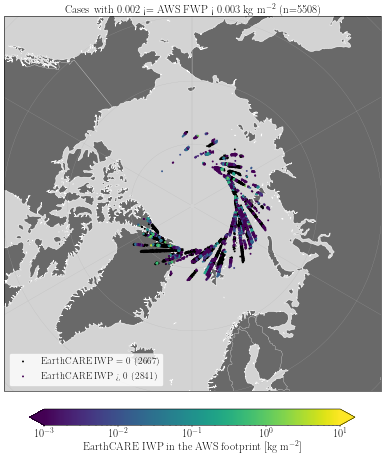

In [5]:
lat = cases["lat"]
lon = cases["lon"]
ea_iwp = cases["ea_iwp"]
clear = ea_iwp <= 0          # EarthCARE saw no ice: cannot go on a log colour scale
 
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(projection=ccrs.NorthPolarStereo())
ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
 
ax.add_feature(cfeature.OCEAN, facecolor="lightgrey", zorder=0)
ax.add_feature(cfeature.LAND, facecolor="dimgrey", zorder=0)
ax.add_feature(cfeature.BORDERS, edgecolor="white", linewidth=0.5, zorder=1)
ax.coastlines(color="white", linewidth=1, zorder=1)
ax.gridlines(draw_labels=False, linewidth=0.3)
 
ax.scatter(lon[clear], lat[clear], s=12, color="black", ec="none",
           transform=ccrs.PlateCarree(), zorder=2,
           label=f"EarthCARE IWP = 0 ({clear.sum()})")
sc = ax.scatter(lon[~clear], lat[~clear], c=ea_iwp[~clear], s=12, ec="none",
                norm=LogNorm(vmin=1e-3, vmax=1e1), cmap="viridis",
                transform=ccrs.PlateCarree(), zorder=3,
                label=f"EarthCARE IWP > 0 ({(~clear).sum()})")
 
fig.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.7, pad=0.04, extend="both",
             label=r"EarthCARE IWP in the AWS footprint [kg m$^{-2}$]")
ax.legend(loc="lower left")
ax.set_title(f"Cases with {fwp_min:g} <= AWS FWP < {fwp_max:g} kg m$^{{-2}}$ "
             f"(n={len(lat)})")
 
#fig_path = Path(args.fig_dir) / f"{Path(args.cases_file).stem}_map.png"
#fig.savefig(fig_path, dpi=200, bbox_inches="tight", facecolor="white")



fraction of cases per surface type (EarthCARE IWP < 1e-2, >= 1e-2):
     ocean:  0.004  0.007
    seaice:  0.450  0.216
      land:  0.057  0.078
     water:  0.000  0.000
      snow:  0.186  0.245
   glacier:  0.060  0.126
     mixed:  0.242  0.327
   missing:  0.000  0.000


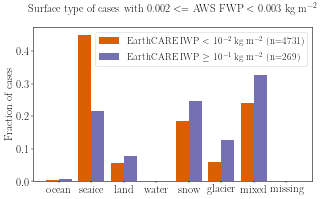

In [6]:
# ============================================================
# SURFACE TYPES
# ============================================================
surface_types = cases["surface_types"]
frac = cases["aws_surface_fractions"]          # (case, surface type)

# a case is the surface with the largest fraction if that fraction is above 0.8,
# otherwise "mixed"; cases with no valid fractions are "missing"
has_frac = np.isfinite(frac).any(axis=1)
frac_filled = np.where(np.isfinite(frac), frac, -1.0)
largest = frac_filled.argmax(axis=1)
largest_frac = frac_filled.max(axis=1)

surface_class = np.where(largest_frac > 0.9,
                         np.array(surface_types)[largest], "mixed")
surface_class[~has_frac] = "missing"

classes = list(surface_types) + ["mixed", "missing"]
low = cases["ea_iwp"] < 1e-2        # EarthCARE saw little or no ice
high = cases["ea_iwp"] >= 1e-1

counts_low = np.array([np.sum((surface_class == c) & low) for c in classes])
counts_high = np.array([np.sum((surface_class == c) & high) for c in classes])

# each colour sums to 1 over the surface types
frac_low = counts_low / counts_low.sum()
frac_high = counts_high / counts_high.sum()

print("\nfraction of cases per surface type (EarthCARE IWP < 1e-2, >= 1e-2):")
for c, f_low, f_high in zip(classes, frac_low, frac_high):
    print(f"  {c:>8s}: {f_low:6.3f} {f_high:6.3f}")

x = np.arange(len(classes))
width = 0.4

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, frac_low, width, color="C1",
       label=rf"EarthCARE IWP $<$ 10$^{{-2}}$ kg m$^{{-2}}$ (n={counts_low.sum()})")
ax.bar(x + width / 2, frac_high, width, color="C2",
       label=rf"EarthCARE IWP $\geq$ 10$^{{-1}}$ kg m$^{{-2}}$ (n={counts_high.sum()})")


ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("Fraction of cases")
ax.set_title(f"Surface type of cases with {fwp_min:g} $<=$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$\n")
ax.legend()

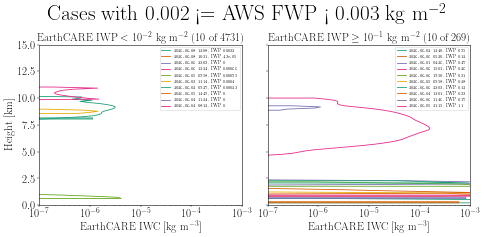

In [7]:
rng = np.random.default_rng(0)   # fixed seed, so the same cases are drawn each time

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, group, title in [
    (axes[0], low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (axes[1], high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = rng.choice(idx, size=min(10, idx.size), replace=False)

    for i in chosen:
        label = f"{pd.Timestamp(cases['time'][i]):%Y-%m-%d %H:%M}, IWP {cases['ea_iwp'][i]:.2g}"
        ax.plot(cases["ea_iwc"][i], cases["ea_height"][i] / 1000, lw=1.5, label=label)

    ax.set_xscale("log")
    ax.set_xlim(1e-7, 1e-3)
    ax.set_xlabel(r"EarthCARE IWC [kg m$^{-3}$]")
    ax.set_title(f"{title} ({chosen.size} of {idx.size})")
    ax.legend(fontsize=8, loc="upper right")

axes[0].set_ylim(0, 15)
axes[0].set_ylabel("Height [km]")
fig.suptitle(f"Cases with {fwp_min:g} <= AWS FWP < {fwp_max:g} kg m$^{{-2}}$")
fig.tight_layout()
plt.show()

KeyError: 'ea_lwc'

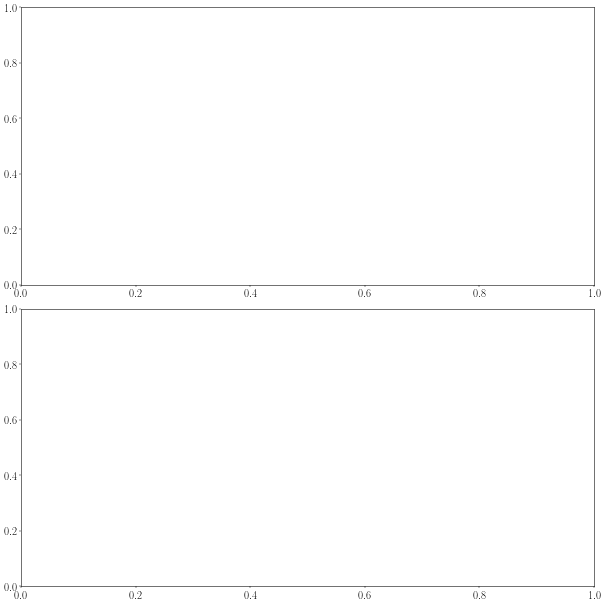

In [9]:
import cmocean as cmc

rng = np.random.default_rng(2)   # fixed seed, so the same cases are drawn each time

fig, axes = plt.subplots(2, 1, figsize=(15, 15), sharey=True, layout="constrained")

for ax, group, title in [
    (axes[0], low, r"EarthCARE IWP $<$ 10$^{-2}$ kg m$^{-2}$"),
    (axes[1], high, r"EarthCARE IWP $\geq$ 10$^{-1}$ kg m$^{-2}$"),
]:
    idx = np.flatnonzero(group)
    chosen = np.sort(rng.choice(idx, size=min(40, idx.size), replace=False))

    iwc = cases["ea_iwc"][chosen]                   # (case, level)
    iwc = cases["ea_lwc"][chosen]                   # (case, level)
    height = cases["ea_height"][chosen] / 1e3       # (case, level), km
    x_2d = np.broadcast_to(np.arange(chosen.size)[:, None], iwc.shape)

    pm = ax.pcolormesh(x_2d.T, height.T, iwc.T,
                       shading="nearest", norm=LogNorm(vmin=1e-6, vmax=1e-3),
                       cmap=cmc.cm.ice)
    pm2 = ax.pcolormesh(x_2d.T, height.T, lwc.T,
                       shading="nearest", norm=LogNorm(vmin=1e-6, vmax=1e-3),
                       cmap=cmc.cm.matter_r)

    # label each column with the case's time
    ax.set_xticks(np.arange(chosen.size))
    ax.set_xticklabels([f"{pd.Timestamp(cases['time'][i]):%m-%d %H:%M}" for i in chosen],
                       rotation=90, fontsize=14)
    ax.set_title(f"{title} ({chosen.size} of {idx.size})")

axes[0].set_ylim(0, 15)
axes[0].set_ylabel("Height [km]")
axes[1].set_ylabel("Height [km]")
fig.colorbar(pm, ax=axes, orientation="horizontal", extend="both", shrink=0.6,
             label=r"EarthCARE IWC [kg m$^{-3}$]")
fig.suptitle(f"Random selection of cases with {fwp_min:g} $\\leq$ AWS FWP $<$ {fwp_max:g} kg m$^{{-2}}$",
             fontsize=24)

# space between the panels, as a fraction of the figure height
fig.get_layout_engine().set(hspace=0.08)

plt.savefig("../figures/aws_band/random_profiles.png",
            facecolor="white", bbox_inches="tight", dpi=200)